## Import the Libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

## Loading the Dataset

In [26]:
df = pd.read_csv('/content/ratings.csv')
df = df[['userId', 'movieId', 'rating']]

## Create User-Item matrix

In [27]:
user_item_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')

## Handle missing values

In [28]:
user_item_matrix_filled = user_item_matrix.fillna(0)

## Applying NMF

In [29]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [30]:
k = 20
nmf = NMF(n_components=k, init='random', random_state=42, max_iter=200)
W = nmf.fit_transform(user_item_matrix_filled)
H = nmf.components_

## Reconstruction of Matrix

In [31]:
nmf_matrix = np.dot(W, H)
nmf_df = pd.DataFrame(nmf_matrix,
                      index=user_item_matrix.index,
                      columns=user_item_matrix.columns)

## Evaluation Metrics

In [32]:
y_true, y_pred = [], []

for row in test_data.itertuples():
    if row.userId in nmf_df.index and row.movieId in nmf_df.columns:
        y_true.append(row.rating)
        y_pred.append(nmf_df.loc[row.userId, row.movieId])

rmse_nmf = np.sqrt(mean_squared_error(y_true, y_pred))

print("RMSE:", rmse_nmf)

RMSE: 2.4582159548759472


In [33]:
def evaluate_rmse(pred_df, test_data):
    y_true, y_pred = [], []

    for row in test_data.itertuples():
        user, movie, rating = row.userId, row.movieId, row.rating

        if user in pred_df.index and movie in pred_df.columns:
            y_true.append(rating)
            y_pred.append(pred_df.loc[user, movie])

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

In [34]:
def precision_recall_at_k(user_id, k=5, threshold=3.5):
    user_pred = nmf_df.loc[user_id].sort_values(ascending=False)

    top_k = user_pred.head(k).index

    if user_id not in user_item_matrix.index:
        return 0, 0

    actual_ratings = user_item_matrix.loc[user_id]
    relevant_items = actual_ratings[actual_ratings >= threshold].index

    if len(relevant_items) == 0:
        return 0, 0

    intersection = set(top_k) & set(relevant_items)

    precision = len(intersection) / k
    recall = len(intersection) / len(relevant_items)

    return precision, recall

In [35]:
def evaluate_precision_recall(k=5, threshold=3.5):
    precisions = []
    recalls = []

    for user_id in nmf_df.index:
        p, r = precision_recall_at_k(user_id, k, threshold)
        precisions.append(p)
        recalls.append(r)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)

    return avg_precision, avg_recall

precision_k, recall_k = evaluate_precision_recall(k=5)

print("Precision@5:", precision_k)
print("Recall@5:", recall_k)

Precision@5: 0.6
Recall@5: 0.06743287173033845


## Prediction of Missing Values

In [36]:
predicted_ratings = nmf_df.copy()

mask = user_item_matrix.isna()
predicted_only = predicted_ratings[mask]

print(predicted_only.head())

movieId    1         2         3         4         5         6         7       \
userId                                                                          
1             NaN  1.048126       NaN  0.040145  0.321829       NaN  0.349166   
2        0.278372  0.126101  0.000000  0.000000  0.018414  0.096314  0.000000   
3        0.087198  0.039424  0.028666  0.000002  0.000017  0.069393  0.000479   
4        1.954110  0.357106  0.314678  0.065473  0.364281  1.004776  0.379547   
5             NaN  0.994131  0.296295  0.087212  0.328511  0.498766  0.373269   

movieId    8         9         10      ...    193565    193567    193571  \
userId                                 ...                                 
1        0.069076  0.170971  1.515857  ...  0.000000  0.000000  0.000000   
2        0.002007  0.000000  0.030390  ...  0.003564  0.003055  0.004073   
3        0.000726  0.000263  0.071159  ...  0.000001  0.000001  0.000001   
4        0.021358  0.161114  0.248840  ...  0.000000

## Top-N Recommendations

In [37]:
def recommend_nmf(user_id, top_n=5):
    user_ratings = nmf_df.loc[user_id]

    already_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = user_ratings.drop(already_rated).sort_values(ascending=False)

    return recommendations.head(top_n)

print(recommend_nmf(1))

movieId
589     4.459315
1200    4.413284
2762    3.321672
1374    3.229055
1036    3.200490
Name: 1, dtype: float64


## Latent Feature Visualization

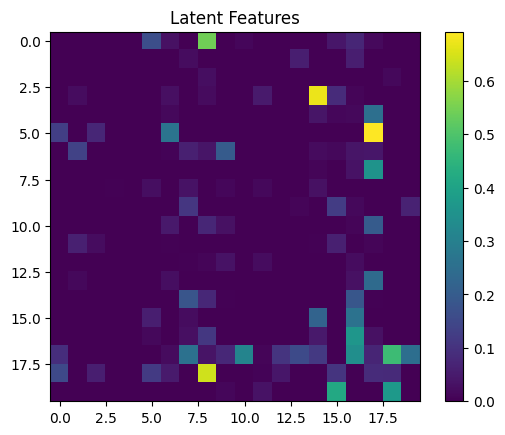

In [38]:
plt.imshow(W[:20])
plt.title("Latent Features")
plt.colorbar()
plt.show()

## Reconstruction Matrix Comparison

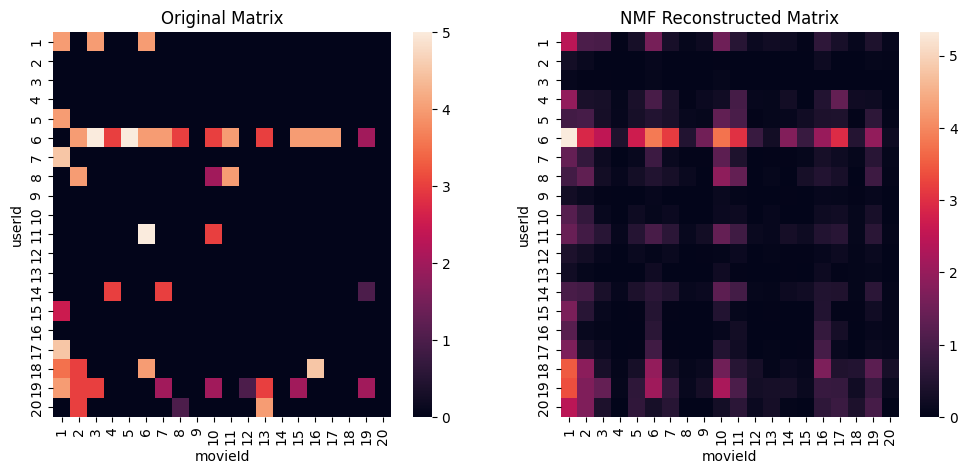

In [39]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(user_item_matrix_filled.iloc[:20, :20])
plt.title("Original Matrix")

plt.subplot(1,2,2)
sns.heatmap(nmf_df.iloc[:20, :20])
plt.title("NMF Reconstructed Matrix")

plt.show()

## SVD vs NMF Performance

NMF RMSE: 2.4582159548759472


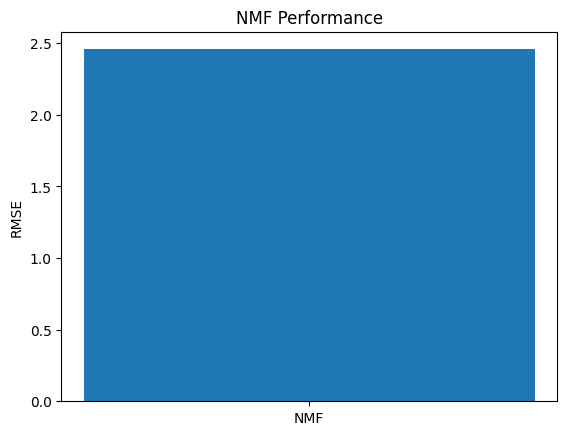

In [40]:
rmse_nmf = evaluate_rmse(nmf_df, test_data)

print("NMF RMSE:", rmse_nmf)

models = ['NMF']
errors = [rmse_nmf]

plt.bar(models, errors)
plt.ylabel("RMSE")
plt.title("NMF Performance")
plt.show()

## Interpretability of NMF Factors

In [41]:
feature_0 = H[0]
top_movies = np.argsort(feature_0)[-10:]
print("Top movies for Feature 0:", top_movies)

Top movies for Feature 0: [2380  981 2281  731 4522 2565 1795 2761 1443 1825]


## Sparsity Handling

In [42]:
sparsity = 1 - (np.count_nonzero(user_item_matrix_filled) / user_item_matrix_filled.size)
print("Sparsity:", sparsity)

Sparsity: 0.9830003169443864


## Recommendation ranking chart

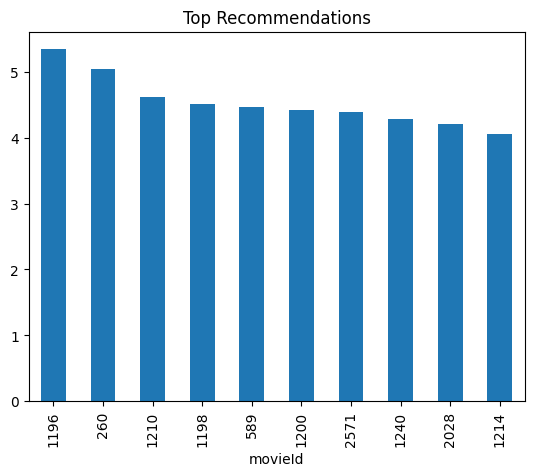

In [43]:
recommendations = nmf_df.loc[1].sort_values(ascending=False).head(10)
recommendations.plot(kind='bar')
plt.title("Top Recommendations")
plt.show()

## Recommendation Diversity

In [44]:
# NOTE: SVD not implemented in this notebook, function kept for reference but disabled
def recommend_svd(user_id, top_n=5):
    raise NotImplementedError("SVD not implemented in this notebook")

In [45]:
def recommend_nmf(user_id, top_n=5):
    user_ratings = nmf_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = user_ratings.drop(already_rated).sort_values(ascending=False)
    return recommendations.head(top_n)

In [46]:
def diversity(recommendations):
    return recommendations.nunique()

user_id = 1

nmf_rec = recommend_nmf(user_id, top_n=10)

print("NMF Recommendations:\n", nmf_rec)

print("NMF Diversity:", diversity(nmf_rec))

NMF Recommendations:
 movieId
589     4.459315
1200    4.413284
2762    3.321672
1374    3.229055
1036    3.200490
541     3.168123
1259    3.158583
1968    3.063025
1356    2.911578
1610    2.901690
Name: 1, dtype: float64
NMF Diversity: 10
